<a href="https://colab.research.google.com/github/AbdullahAmir1562003/Gym-Management-System/blob/main/Used_Vehicle_Valuation_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Environment ready!")

Environment ready!


In [ ]:
# Direct working URL for CarDekho vehicle dataset
url = "https://raw.githubusercontent.com/roshancyriacmathew/Car-price-prediction-using-Linear-regression-Machine-Learning-Project/main/car%20data.csv"
df = pd.read_csv(url)

# Preview shape and columns
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (301, 9)

First 5 rows:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
# Check for null values
print("Missing values per column:")
print(df.isnull().sum())

# Calculate vehicle age relative to the current year
df['Vehicle_Age'] = 2026 - df['Year']

# Drop original Year and Car_Name columns
df_clean = df.drop(columns=['Car_Name', 'Year'])

print("\nUpdated DataFrame Preview:")
df_clean.head()

Missing values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Updated DataFrame Preview:


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [ ]:
# Separate features (X) and target (y)
X = df_clean.drop(columns=['Selling_Price'])
y = df_clean['Selling_Price']

# Split: 80% training set, 20% testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Features: {list(X.columns)}")
print(f"X_train rows: {X_train.shape[0]}, X_test rows: {X_test.shape[0]}")

Features: ['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Vehicle_Age']
X_train rows: 240, X_test rows: 61


In [ ]:
# Group column types
num_cols = ['Present_Price', 'Kms_Driven', 'Owner', 'Vehicle_Age']
cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']

# Construct the transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [ ]:
# Define candidate models wrapped inside pipelines
models = {
    "Linear Regression": Pipeline(steps=[('prep', preprocessor), ('reg', LinearRegression())]),
    "Random Forest": Pipeline(steps=[('prep', preprocessor), ('reg', RandomForestRegressor(random_state=42))]),
    "XGBoost": Pipeline(steps=[('prep', preprocessor), ('reg', XGBRegressor(random_state=42, n_estimators=100))])
}

# Train and evaluate each model on test data
performance = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    performance.append({"Model": name, "R² Score": round(r2, 4), "MAE": round(mae, 4), "RMSE": round(rmse, 4)})

# Display benchmark table
results_df = pd.DataFrame(performance)
results_df

,Model,R² Score,MAE,RMSE
0,Linear Regression,0.8490,1.2162,1.8652
1,Random Forest,0.9621,0.6218,0.9342
2,XGBoost,0.9568,0.5985,0.9975


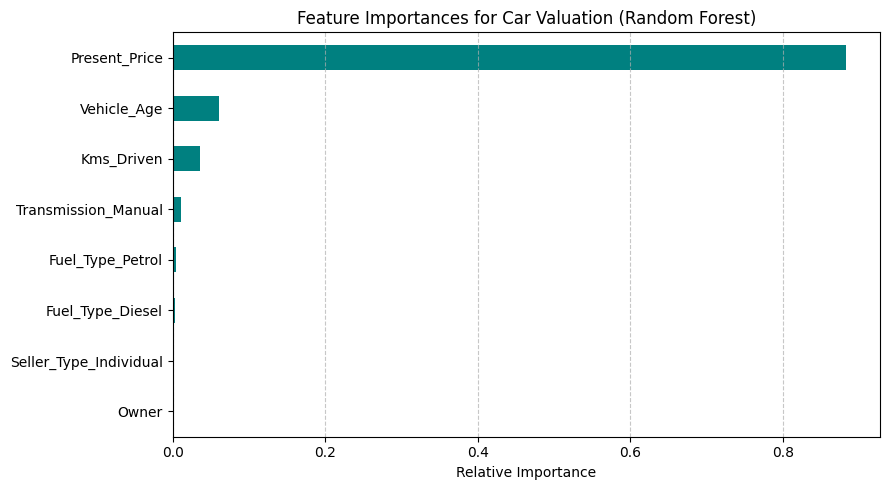

In [ ]:
# Extract the trained Random Forest model and transformed feature names
rf_model = models["Random Forest"].named_steps['reg']
ohe_feature_names = models["Random Forest"].named_steps['prep'].named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(ohe_feature_names)

# Create importance series
importances = pd.Series(rf_model.feature_importances_, index=all_feature_names).sort_values(ascending=True)

# Plot feature importances
plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importances for Car Valuation (Random Forest)')
plt.xlabel('Relative Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
import joblib

# 1. Save the best pipeline (Random Forest)
best_pipeline = models["Random Forest"]
joblib.dump(best_pipeline, "vehicle_valuation_engine.pkl")
print("Saved pipeline as 'vehicle_valuation_engine.pkl'!")

# 2. Load it back for inference
loaded_engine = joblib.load("vehicle_valuation_engine.pkl")

# 3. Create a test sample car with raw values
# Features: Present_Price, Kms_Driven, Owner, Vehicle_Age, Fuel_Type, Seller_Type, Transmission
sample_car = pd.DataFrame([{
    'Present_Price': 8.5,       # Original price (in Lakhs)
    'Kms_Driven': 32000,        # Total kilometers
    'Owner': 0,                 # First-hand owner
    'Vehicle_Age': 5,           # 5 years old
    'Fuel_Type': 'Petrol',      # 'Petrol', 'Diesel', or 'CNG'
    'Seller_Type': 'Dealer',    # 'Dealer' or 'Individual'
    'Transmission': 'Manual'    # 'Manual' or 'Automatic'
}])

# 4. Predict fair resale price
predicted_price = loaded_engine.predict(sample_car)[0]
print(f"\n--- Valuation Result ---")
print(f"Estimated Market Value: {predicted_price:.2f} Lakhs")

Saved pipeline as 'vehicle_valuation_engine.pkl'!

--- Valuation Result ---
Estimated Market Value: 6.69 Lakhs


In [ ]:
!pip install -q gradio

import gradio as gr
import joblib
import pandas as pd

# 1. Load the trained valuation pipeline
engine = joblib.load("vehicle_valuation_engine.pkl")

# 2. Define the prediction function connected to the UI
def estimate_price(present_price, kms_driven, vehicle_age, fuel_type, seller_type, transmission, owner_count):
    # Construct DataFrame with exact column names expected by pipeline
    input_df = pd.DataFrame([{
        'Present_Price': float(present_price),
        'Kms_Driven': int(kms_driven),
        'Owner': int(owner_count),
        'Vehicle_Age': int(vehicle_age),
        'Fuel_Type': str(fuel_type),
        'Seller_Type': str(seller_type),
        'Transmission': str(transmission)
    }])

    # Generate prediction and safeguard against negative valuations
    raw_pred = engine.predict(input_df)[0]
    final_pred = max(0.1, round(raw_pred, 2))

    return f"Estimated Resale Value: {final_pred} Lakhs"

# 3. Create the interactive web layout
demo = gr.Interface(
    fn=estimate_price,
    inputs=[
        gr.Number(label="Showroom / Original Price (in Lakhs)", value=7.5),
        gr.Slider(minimum=0, maximum=300000, step=1000, label="Kilometers Driven", value=35000),
        gr.Slider(minimum=0, maximum=25, step=1, label="Vehicle Age (Years)", value=4),
        gr.Dropdown(choices=["Petrol", "Diesel", "CNG"], label="Fuel Type", value="Petrol"),
        gr.Dropdown(choices=["Dealer", "Individual"], label="Seller Type", value="Dealer"),
        gr.Dropdown(choices=["Manual", "Automatic"], label="Transmission", value="Manual"),
        gr.Radio(choices=[0, 1, 3], label="Previous Owners", value=0)
    ],
    outputs=gr.Textbox(label="Predicted Valuation"),
    title="Used Vehicle Valuation Engine",
    description="Adjust vehicle specifications to compute live market resale estimates using the trained Random Forest model."
)

# Launch the app inline inside Google Colab
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://40eba566dca02f8e7c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
